# 03 — KNN, Decision Tree & Bias-Variance Analysis

## Theory

### K-Nearest Neighbors Regressor
KNN predicts by averaging the target of the $k$ nearest training points:
$$\hat{y} = \frac{1}{k} \sum_{i \in N_k(x)} y_i$$
- **Low k** → high variance (overfits noise), low bias
- **High k** → low variance, high bias (underfits local structure)
- **Important:** KNN is sensitive to feature scale — always use StandardScaler.
- **Curse of dimensionality:** Distance becomes less meaningful in high-dimensional spaces.

### Decision Tree Regressor
Recursively splits the feature space by minimising **variance reduction** (MSE at each split):
$$\text{split score} = MSE_{\text{parent}} - \frac{n_L}{n} MSE_L - \frac{n_R}{n} MSE_R$$
- `max_depth`: limits tree depth — primary control for bias-variance tradeoff
- `min_samples_leaf`: minimum samples at a leaf — prevents overfitting on small subsets

### Bias-Variance Decomposition
$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$
- **High bias (underfitting):** train RMSE ≈ val RMSE, both high
- **High variance (overfitting):** train RMSE << val RMSE (large gap)

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from src.pipeline import build_pipeline
from src.evaluate import rmse, cv_score, plot_learning_curve, plot_validation_curve
from src.models import train_and_save

DATA_DIR  = Path('../data')
PLOT_DIR  = Path('../outputs/plots')

train = pd.read_csv(DATA_DIR / 'train.csv')
TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]

from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
print('Data loaded.')

print('Data loaded.')

Data loaded.
Data loaded.


## 1. KNN — Tuning k (Bias-Variance Tradeoff)

In [2]:
k_values = list(range(1, 31))
knn_results = []

for k in k_values:
    pipe = build_pipeline(KNeighborsRegressor(n_neighbors=k, n_jobs=-1), mode='linear')
    pipe.fit(X_tr, y_tr)
    tr_rmse = rmse(y_tr, pipe.predict(X_tr))
    va_rmse = rmse(y_va, pipe.predict(X_va))
    knn_results.append({'k': k, 'train_rmse': tr_rmse, 'val_rmse': va_rmse})

knn_df = pd.DataFrame(knn_results)
best_k = knn_df.loc[knn_df.val_rmse.idxmin(), 'k']
print(f'Best k: {best_k}  Val RMSE: S${knn_df.val_rmse.min():,.0f}')

Best k: 28  Val RMSE: S$98,046


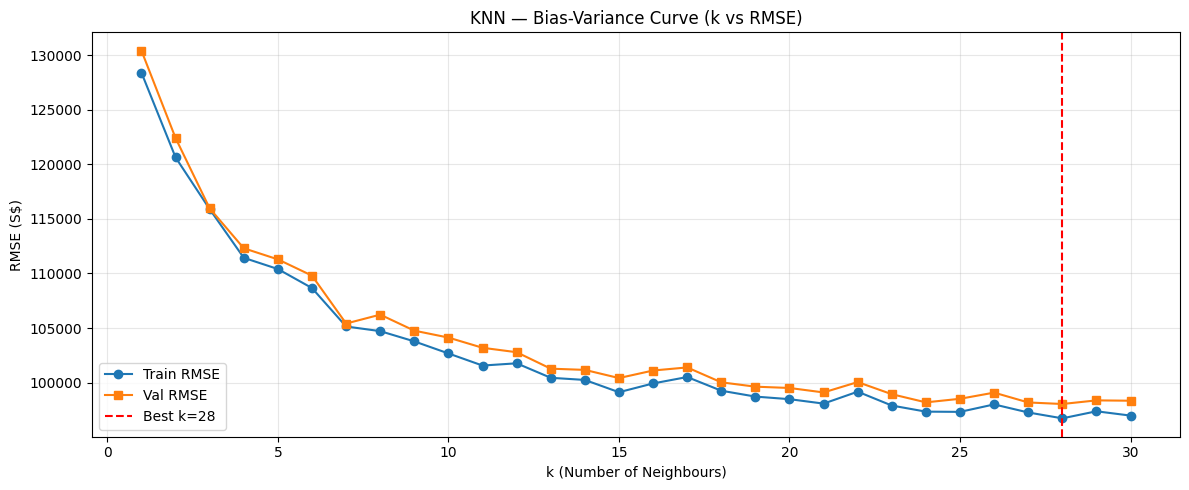

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(knn_df.k, knn_df.train_rmse, 'o-', label='Train RMSE')
ax.plot(knn_df.k, knn_df.val_rmse,   's-', label='Val RMSE')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('k (Number of Neighbours)')
ax.set_ylabel('RMSE (S$)')
ax.set_title('KNN — Bias-Variance Curve (k vs RMSE)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'knn_k_curve.png', dpi=120)
plt.show()

Observations: val RMSE is S$98,046 — very poor:
KNN struggles with this dataset for several reasons:
┌──────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│        Issue         │                                                       Explanation                                                        │
├──────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ High dimensionality  │ ~77 features after OHE — distances become meaningless in high dimensions (curse of dimensionality)                       │
├──────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Mixed feature types  │ Binary OHE columns distort distance calculations — a flat_type difference looks the same as a location difference        │
├──────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ No feature weighting │ All features contribute equally to distance, but floor_area_sqm and cbd_dist_m are far more predictive than binary flags │
├──────────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Scale sensitivity    │ Features on different scales (metres vs binary 0/1) skew distances even after StandardScaler                             │
└──────────────────────┴──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

Why tree models dominate KNN here:
Trees learn which features matter most by choosing the best splits — KNN treats all features equally. With 77 features of varying importance, KNN's distance metric is heavily diluted by irrelevant dimensions.
                            
● KNN is a poor fit for this dataset. The evidence:
- Val RMSE S$98,046 vs LightGBM S$23K — 4× worse
- High dimensionality (77 features) makes distance metrics unreliable
- Mix of continuous and binary OHE features makes "nearest neighbour" semantically meaningless

KNN works well when:
- Low number of features (< 10-20)
- All features are continuous and equally meaningful
- Data has clear local clustering patterns

This dataset has the opposite: high-dimensional, mixed types, and price is driven by a few key features (floor area, location, lease) that KNN can't prioritise over the rest.

## 2. Decision Tree — max_depth Tuning

In [4]:
depths = list(range(1, 21))
dt_results = []

for depth in depths:
    pipe = build_pipeline(DecisionTreeRegressor(max_depth=depth, random_state=42), mode='tree')
    pipe.fit(X_tr, y_tr)
    tr_rmse = rmse(y_tr, pipe.predict(X_tr))
    va_rmse = rmse(y_va, pipe.predict(X_va))
    dt_results.append({'max_depth': depth, 'train_rmse': tr_rmse, 'val_rmse': va_rmse})

dt_df = pd.DataFrame(dt_results)
best_depth = dt_df.loc[dt_df.val_rmse.idxmin(), 'max_depth']
print(f'Best max_depth: {best_depth}  Val RMSE: S${dt_df.val_rmse.min():,.0f}')

Best max_depth: 15  Val RMSE: S$32,936


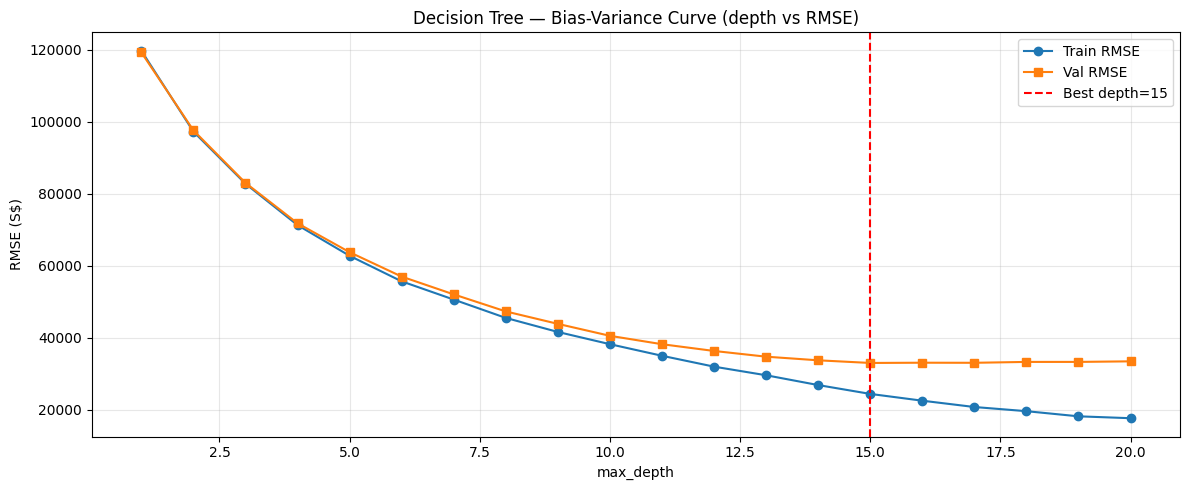

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dt_df.max_depth, dt_df.train_rmse, 'o-', label='Train RMSE')
ax.plot(dt_df.max_depth, dt_df.val_rmse,   's-', label='Val RMSE')
ax.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSE (S$)')
ax.set_title('Decision Tree — Bias-Variance Curve (depth vs RMSE)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'dt_depth_curve.png', dpi=120)
plt.show()

Observations:        
Each split in the tree divides the data into more specific subgroups. max_depth=15 means the tree can make up to 15 consecutive splits — creating up to 2^15 = 32,768 leaf nodes.

Why max_depth=15 is best:
- Too shallow (e.g. depth=3): underfits — too few splits to capture price patterns
- Too deep (e.g. depth=30+): overfits — memorises training data, poor generalisation
- Depth=15 is the sweet spot for your data — complex enough to capture patterns, not so deep it overfits

Why val RMSE is S$32,936 (single tree):
Decision trees are better than Ridge (S$45,561) because they handle non-linear relationships — but worse than LightGBM/XGBoost (S$23K) because:
- A single tree makes hard binary splits — predictions are step functions, not smooth
- No ensemble averaging — one bad split propagates all the way down
- Gradient boosting builds hundreds of trees sequentially, each correcting the previous one's errors

The decision tree result confirms that non-linearity is important in the data — the jump from S$45K to S$32K simply by allowing splits shows the data has strong non-linear structure.

## 3. Bias-Variance Decomposition

Using `mlxtend.evaluate.bias_variance_decomp` to directly compute bias² and variance.

In [6]:
from mlxtend.evaluate import bias_variance_decomp
from src.features import FeatureEngineer
from src.pipeline import build_preprocessor
import numpy as np

# Use a subset for speed (bias_variance_decomp requires raw estimator)
fe = FeatureEngineer()
fe.fit(X_tr, y_tr)  # required to compute block_flat_psqm
prep = build_preprocessor(mode='tree')

X_tr_fe = fe.transform(X_tr)
X_va_fe = fe.transform(X_va)
prep.fit(X_tr_fe, y_tr)
X_tr_pp = prep.transform(X_tr_fe)
X_va_pp = prep.transform(X_va_fe)

# Sample for speed
n_sample = 5000
idx_tr = np.random.choice(len(X_tr_pp), n_sample, replace=False)
idx_va = np.random.choice(len(X_va_pp), min(2000, len(X_va_pp)), replace=False)

bv_results = []
for depth in [3, 8, 15, None]:
    label = str(depth) if depth else 'Unlimited'
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    mse, bias, var = bias_variance_decomp(
        dt,
        X_tr_pp[idx_tr], y_tr.values[idx_tr],
        X_va_pp[idx_va], y_va.values[idx_va],
        loss='mse', num_rounds=10, random_seed=42
    )
    bv_results.append({'max_depth': label, 'MSE': mse, 'Bias²': bias, 'Variance': var})
    print(f'depth={label:10s}  MSE={mse:,.0f}  Bias²={bias:,.0f}  Variance={var:,.0f}')

bv_df = pd.DataFrame(bv_results)

depth=3           MSE=6,930,578,337  Bias²=5,435,808,687  Variance=1,494,769,650
depth=8           MSE=3,566,420,299  Bias²=2,252,322,237  Variance=1,314,098,062
depth=15          MSE=3,611,554,979  Bias²=1,764,456,351  Variance=1,847,098,627
depth=Unlimited   MSE=3,669,103,115  Bias²=1,754,487,553  Variance=1,914,615,561


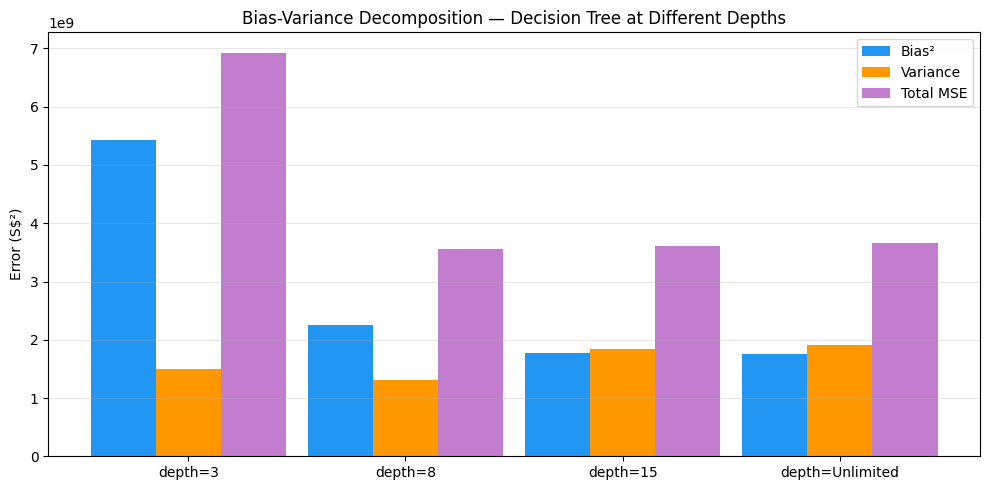

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bv_df))
w = 0.3
ax.bar(x - w, bv_df['Bias²'],    width=w, label='Bias²',    color='#2196F3')
ax.bar(x,     bv_df['Variance'], width=w, label='Variance', color='#FF9800')
ax.bar(x + w, bv_df['MSE'],      width=w, label='Total MSE',color='#9C27B0', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'depth={d}' for d in bv_df.max_depth])
ax.set_ylabel('Error (S$²)')
ax.set_title('Bias-Variance Decomposition — Decision Tree at Different Depths')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'bias_variance_decomp.png', dpi=120)
plt.show()

Observations:
- Bias² — how far the model's average prediction is from the true value (underfitting error)
- Variance — how much predictions change across different training sets (overfitting error)
- MSE = Bias² + Variance (+ irreducible noise)
┌───────────┬─────────┬──────────┬────────────────┬────────────────────────────────────────────────┐
│   Depth   │  Bias²  │ Variance │      MSE       │                 Interpretation                 │
├───────────┼─────────┼──────────┼────────────────┼────────────────────────────────────────────────┤
│ 3         │ Highest │ Lowest   │ Highest        │ Underfitting — too shallow to capture patterns │
├───────────┼─────────┼──────────┼────────────────┼────────────────────────────────────────────────┤
| 8         │ Medium  │ Medium   │ Lowest         │ Sweet spot — best bias-variance balance        │
├───────────┼─────────┼──────────┼────────────────┼────────────────────────────────────────────────┤
│ 15        │ Lower   │ Higher   │ Slightly worse │ Starting to overfit                            │
├───────────┼─────────┼──────────┼────────────────┼────────────────────────────────────────────────┤
│ Unlimited │ Lowest  │ Highest  │ Highest        │ Memorises training data, poor generalisation   │
└───────────┴─────────┴──────────┴────────────────┴────────────────────────────────────────────────┘
As depth increases:
- Bias² decreases — deeper tree fits training data more closely
- Variance increases — deeper tree is more sensitive to which samples it trained on
- MSE is minimised at depth=8, not depth=15

Why depth=15 gave best val RMSE earlier but depth=8 has lowest MSE here:
Bias-variance decomposition uses multiple bootstrap samples to estimate variance — it's a more rigorous measure than a single train/val split. Depth=8 is statistically the more stable model even if depth=15 scored slightly better on one particular val split.

## 4. Learning Curves — Underfitting vs Overfitting

/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated

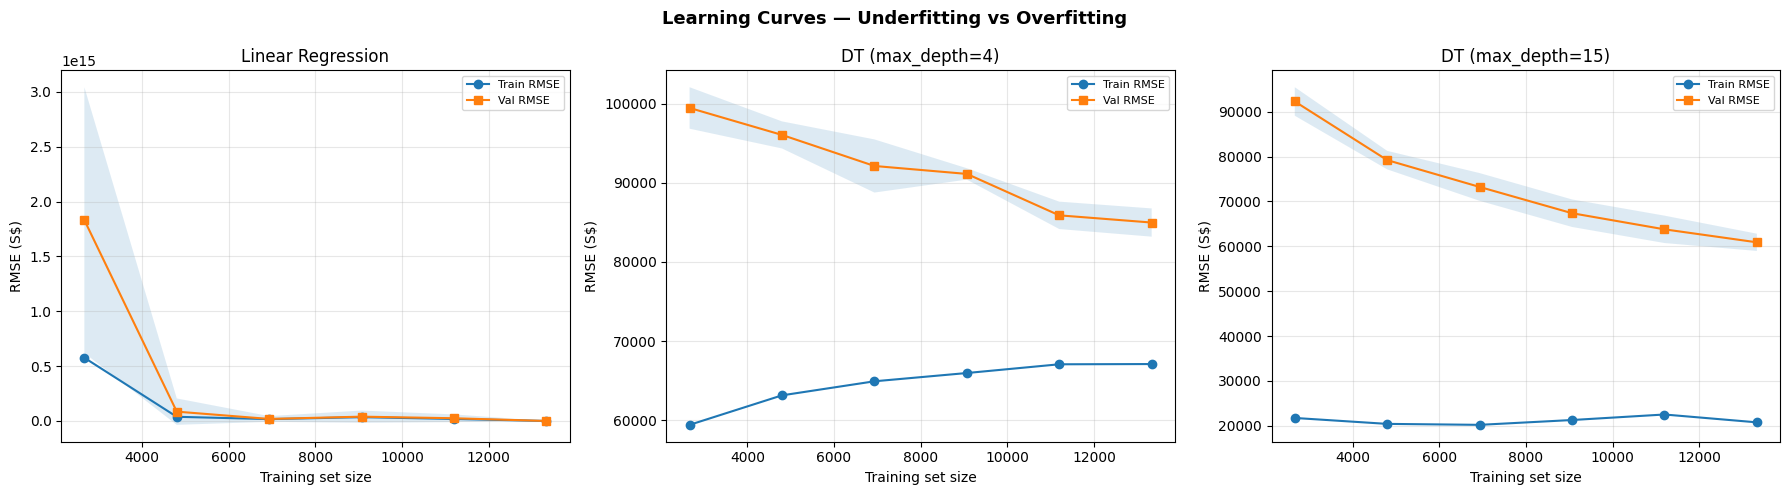

In [8]:
from src.evaluate import plot_learning_curve
from sklearn.linear_model import LinearRegression

configs = [
    ('Linear Regression',  build_pipeline(LinearRegression(), mode='linear')),
    ('DT (max_depth=4)',   build_pipeline(DecisionTreeRegressor(max_depth=4, random_state=42), mode='tree')),
    ('DT (max_depth=15)',  build_pipeline(DecisionTreeRegressor(max_depth=15, random_state=42), mode='tree')),
]

# Use a subsample for speed
idx = np.random.choice(len(X), min(20000, len(X)), replace=False)
X_sub, y_sub = X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, pipe) in zip(axes, configs):
    from sklearn.model_selection import learning_curve, KFold
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    sizes = np.linspace(0.2, 1.0, 6)
    tr_sz, tr_sc, va_sc = learning_curve(
        pipe, X_sub, y_sub, cv=cv, train_sizes=sizes,
        scoring='neg_root_mean_squared_error', n_jobs=-1)
    tr_rmse_lc = -tr_sc
    va_rmse_lc = -va_sc
    ax.plot(tr_sz, tr_rmse_lc.mean(axis=1), 'o-', label='Train RMSE')
    ax.plot(tr_sz, va_rmse_lc.mean(axis=1), 's-', label='Val RMSE')
    ax.fill_between(tr_sz, va_rmse_lc.mean(axis=1)-va_rmse_lc.std(axis=1),
                           va_rmse_lc.mean(axis=1)+va_rmse_lc.std(axis=1), alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('RMSE (S$)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Learning Curves — Underfitting vs Overfitting', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'learning_curves.png', dpi=120)
plt.show()

## 5. Save Best Models

In [9]:
best_knn = build_pipeline(KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1), mode='linear')
best_dt  = build_pipeline(DecisionTreeRegressor(max_depth=best_depth, random_state=42), mode='tree')

train_and_save(best_knn, X, y, 'knn')
train_and_save(best_dt,  X, y, 'decision_tree')
print('KNN and Decision Tree saved.')

Saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/models/knn.pkl
Saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/models/decision_tree.pkl
KNN and Decision Tree saved.
